In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
mouse = 0
day = 0
session_type = 'OF1'
sorter = 'kilosort4'
storage = Path('/Users/harryclark/Downloads/COHORT12/')

alpha = 0.001
n_jobs = 8
n_shuffles = 100
seed = 1
class Args:
    def __init__(self,mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed):
        self.mouse = mouse
        self.day = day
        self.session_type = session_type
        self.sorter = sorter
        self.storage = storage
        self.alpha = alpha
        self.n_jobs = n_jobs
        self.n_shuffles = n_shuffles
        self.seed = seed
args = Args(mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed)

In [3]:
def load_cluster_locations(clusters, cells):
    for column in ['coord_SCs_x', 'coord_SCs_y', 'coord_SCs_z', 'coord_probe_x', 'coord_probe_y','brain_region']:
        vals = []
        for id in cells.cluster_id:
            vals.append(clusters[column][id])
        cells[column] = vals
    return cells

In [4]:
args.session_type = 'OF1'

# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

for session_path in sorted(
    list(args.storage.glob(f'*/*/{args.session_type}/*{args.session_type}_beh.nwb'))
): 
    print(session_path)
    args.mouse = int(session_path.parent.parent.parent.name[1:])
    args.day = int(session_path.parent.parent.name[1:])
    mouse_day = f'M{args.mouse}D{args.day}'
    mouse = args.mouse
    day = args.day
    
    # remove M22 
    if mouse == 22:
        continue

    [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, percentile_threshold=95, 
                                                              disqualifying_brain_areas_for_grid_cells=disqualifying_brain_areas_for_grid_cells)
    _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

    gcs = load_cluster_locations(clusters_VR, cells=gcs)
    ngs = load_cluster_locations(clusters_VR, cells=ngs)
    ns = load_cluster_locations(clusters_VR, cells=ns)
    sc = load_cluster_locations(clusters_VR, cells=sc)
    ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
    all = load_cluster_locations(clusters_VR, cells=all)
    
    gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
    ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
    ns_ = pd.concat([ns_, ns], ignore_index=True)
    sc_ = pd.concat([sc_, sc], ignore_index=True)
    ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
    all_ = pd.concat([all_, all], ignore_index=True)

    print(f'there are this many cells at the moment, {len(all_)}')

/Users/harryclark/Downloads/COHORT12/M20/D14/OF1/sub-20_day-14_ses-OF1_beh.nwb
20 14
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are this many cells at the moment, 204
/Users/harryclark/Downloads/COHORT12/M20/D15/OF1/sub-20_day-15_ses-OF1_beh.nwb
20 15
there are 61 non_grid and non_spatial_cells
there are 1 grid_cells
there are 50 non grid spatial cells
there are 11 non spatial cells
there are 11 speed cells
there are 73 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm3']
there are this many cells at the moment, 277
/Users/harryclark/Downloads/COHORT12/M20/D16/OF1/sub-20_day-16_ses-OF1_beh.nwb
20 16
there are 178 non_grid and non_spatial_cells
there are 3 grid_cells
the

Plotting for mouse 20
unique brain regions: ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'VISp2/3' 'VISl2/3' 'VISpl2/3' 'VISl1'
 'root' 'VISp1' 'VISpl5']


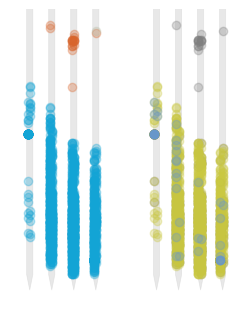

Plotting for mouse 21
unique brain regions: ['ENTm2' 'ENTm1' 'ENTm3' 'ENTm5' 'ENTm6' 'root' 'ENTl6a' 'VISpor6a'
 'VISpl6a' 'VISpor5' 'VISpl5' 'VISl5' 'VISl4' 'VISl2/3' 'HPF' 'dhc' 'or'
 'VISpor6b' 'VISl6a' 'ec' 'VISpl6b' 'VISp6a' 'VISp5' 'VISpl4' 'VISpl2/3'
 'VISl1']


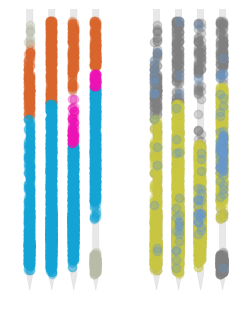

Plotting for mouse 25
unique brain regions: ['FL' 'root' 'ENTm2' 'ENTm1' 'ENTm3' 'PAR' 'VISpl5' 'ENTm5' 'VISp5'
 'VISpl4' 'VISpl2/3' 'VISp2/3' 'VISpl1' 'VISl1' 'VISp4']


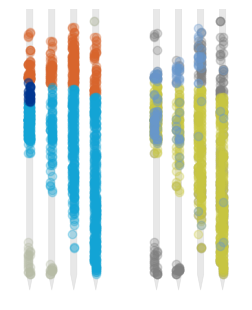

Plotting for mouse 26
unique brain regions: ['ENTm1' 'ENTm2' 'ENTm3' 'VISpl5' 'VISpl4' 'ENTm5' 'VISpor5' 'root' 'SIM'
 'PAR' 'VISpl6a' 'VISp5' 'VISp4' 'VISl4' 'VISl2/3' 'VISpl2/3' 'VISp2/3']


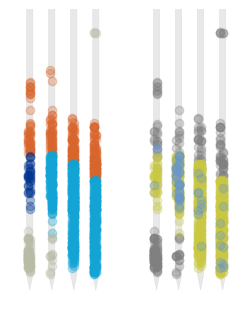

Plotting for mouse 27
unique brain regions: ['mcp' 'arb' 'FL' 'PFL' 'root' 'CUL4, 5' 'SIM' 'ENTm2' 'PAR' 'ENTm1'
 'VISpl5' 'VISpl6a' 'APr' 'RSPd6a' 'ENTm3' 'ENTm5']


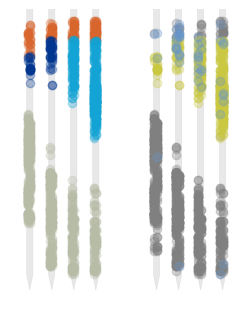

Plotting for mouse 28
unique brain regions: ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a' 'VISpl5' 'APr' 'VISp5'
 'VISp4' 'VISp2/3' 'VISl5' 'VISpl4' 'VISl4' 'VISl2/3' 'root' 'VISpor5'
 'VISl1' 'VISp1' 'VISp6a']


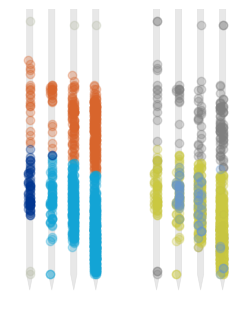

Plotting for mouse 29
unique brain regions: ['root' 'ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'APr' 'VISpl6a' 'VISpl5'
 'VISpl4' 'VISp2/3' 'VISp1' 'VISl2/3' 'VISp5' 'VISp6a']


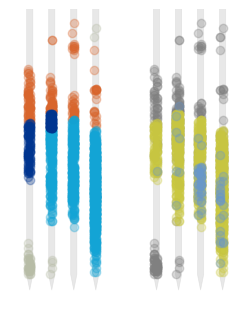

In [14]:
for mouse in [20,21,25,26,27,28,29]:
    print(f'Plotting for mouse {mouse}')
    print('unique brain regions:', all_[all_['mouse'] == mouse]['brain_region'].unique())
    mouse_all = all_[all_['mouse'] == mouse]
    mouse_vis = mouse_all[mouse_all['brain_region'].str.contains('VIS|APr')]
    mouse_ent = mouse_all[mouse_all['brain_region'].str.contains('ENT')]
    mouse_par = mouse_all[mouse_all['brain_region'].str.contains('PAR')]
    mouse_hpf = mouse_all[mouse_all['brain_region'].str.contains('HPF')]
    mouse_cere = mouse_all[mouse_all['brain_region'].str.contains('PFL|FL|SIM|root|mcp|CUL')]
    fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(3, 12), squeeze=False)
    plot_NP2_probe(ax[0,0], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa')
    ax[0,0].scatter(mouse_vis['probe_x'], mouse_vis['probe_y'], color="#D8652C", alpha=0.3)
    ax[0,0].scatter(mouse_ent['probe_x'], mouse_ent['probe_y'], color="#13A4D5", alpha=0.3)
    ax[0,0].scatter(mouse_par['probe_x'], mouse_par['probe_y'], color="#003590", alpha=0.3)
    ax[0,0].scatter(mouse_cere['probe_x'], mouse_cere['probe_y'], color="#B7BCA6", alpha=0.3)
    ax[0,0].scatter(mouse_hpf['probe_x'], mouse_hpf['probe_y'], color="#EF13B4", alpha=0.3)
    mouse_ns = ns_[ns_['mouse'] == mouse]
    mouse_ngs = ngs_[ngs_['mouse'] == mouse]
    mouse_gcs = gcs_[gcs_['mouse'] == mouse]

    mouse_ngs = mouse_all[mouse_all['brain_region'].str.contains('ENT|PAR')]
    mouse_cere = mouse_all[mouse_all['brain_region'].str.contains('PFL|FL|SIM|root|mcp|CUL')]

    plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa')
    ax[0,1].scatter(mouse_cere['probe_x'], mouse_cere['probe_y'], color='grey', alpha=0.3)
    ax[0,1].scatter(mouse_ns['probe_x'], mouse_ns['probe_y'], color='grey', alpha=0.3)
    ax[0,1].scatter(mouse_ngs['probe_x'], mouse_ngs['probe_y'], color='#CAC841', alpha=0.3)
    ax[0,1].scatter(mouse_gcs['probe_x'], mouse_gcs['probe_y'], color='#6897CD', alpha=0.3)
    plt.show()